## **Long Short-Term Memory (LSTM)**

### **Concept**
**LSTM** is a specialized Recurrent Neural Network (RNN) designed to process **sequences** rather than individual data points. Unlike standard regression models, LSTMs maintain an internal "memory state," allowing them to learn temporal dependencies over time.


### **Why this fits Reservoir Data**
Hydrological systems have **"Memory"**: rain that fell 5 days ago often impacts storage levels today due to soil saturation and upstream flow time. LSTMs are mathematically designed to capture these lag effects better than any other architecture.

### **Configuration**
* **Input Structure:** 3D Sequences `(Samples, Time Steps, Features)`.
* **Lookback Window:** 10 Days (The model looks at the past 10 days to predict Day 11).
* **Regularization:** **Dropout layers** are included to randomly "forget" connections during training, forcing the model to be robust and preventing overfitting.

**Import Required libraries and Modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import sys
import os

**Setup & Data Loading**

In [2]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/EDI-III Project/Data/Processed Data'
else:
    BASE_PATH = '.'

file_path = os.path.join(BASE_PATH, 'Chembarambakkam.csv')
print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if df.index.duplicated().any():
        print(f"Warning: Found {df.index.duplicated().sum()} duplicate dates. Keeping the first occurrence.")
        df = df[~df.index.duplicated(keep='first')]

    df = df.asfreq('D')

    df = df.ffill()
except FileNotFoundError:
    print("Error: File not found. Please run the Data Processing script first.")
    sys.exit()

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/EDI-III Project/Data/Processed Data/Chembarambakkam.csv


**Data Preperation for LSTM**

In [3]:
data = df.values # Convert to numpy array
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

SEQ_LENGTH = 10

def create_sequences(dataset, seq_length):
    X, y = [], []

    target_idx = df.columns.get_loc('Storage (mcft)')

    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length]) # Sequence of features
        y.append(dataset[i+seq_length, target_idx]) # Target value (Storage)
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LENGTH)

print(f"Input Shape: {X.shape} (Samples, Time Steps, Features)")

Input Shape: (7532, 10, 26) (Samples, Time Steps, Features)


**Train & Test Data Split**

In [4]:
test_days = 730
train_size = len(X) - test_days

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Train samples: 6802
Test samples: 730


**Build LSTM Architecture**

In [5]:
print("\nBuilding LSTM Model...")
model = Sequential()

# LSTM with return_sequences=True (to stack another LSTM layer)
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Prevent overfitting

#Standard LSTM
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

#Dense Output
model.add(Dense(units=1)) # Prediction of single value (Storage)

model.compile(optimizer='adam', loss='mean_squared_error')


Building LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Train Model**

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0107 - val_loss: 6.3869e-04
Epoch 2/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 3/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 4/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0024 - val_loss: 4.4021e-04
Epoch 5/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0020 - val_loss: 3.1647e-04
Epoch 6/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0020 - val_loss: 0.0032
Epoch 7/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0023 - val_loss: 2.5223e-04
Epoch 8/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 9/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 10/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0016 - val_loss: 2.6378e-04
Epoch 11/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0014 - val_loss: 1.9847e-04
Epoch 12/40
426/426 ━━━━━━━━

**Prediction and Inverse scaling**

In [7]:
print("\nGenerating Predictions...")
predictions = model.predict(X_test)

dummy_array = np.zeros((len(predictions), scaled_data.shape[1]))
target_idx = df.columns.get_loc('Storage (mcft)')
dummy_array[:, target_idx] = predictions.flatten()

# Inverse transform
inversed_predictions = scaler.inverse_transform(dummy_array)[:, target_idx]

# Do the same for y_test (Actuals)
dummy_array_y = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_array_y[:, target_idx] = y_test
inversed_actuals = scaler.inverse_transform(dummy_array_y)[:, target_idx]


Generating Predictions...
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


**Evaluation**

In [8]:
# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(inversed_actuals, inversed_predictions))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(inversed_actuals, inversed_predictions)

# MAPE (Mean Absolute Percentage Error)
# We add a tiny epsilon (1e-10) to actuals to avoid division by zero
mape = np.mean(np.abs((inversed_actuals - inversed_predictions) / (inversed_actuals + 1e-10))) * 100

# R-squared (R2)
r2 = r2_score(inversed_actuals, inversed_predictions)

# Print Results
print(f"\n{'='*30}")
print(f"LSTM Model")
print(f"{'='*30}")
print(f"RMSE : {rmse:.2f} mcft")
print(f"MAE  : {mae:.2f} mcft")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")
print(f"{'='*30}")



LSTM Model
RMSE : 39.92 mcft
MAE  : 24.62 mcft
MAPE : 0.97 %
R²   : 0.9948


**Visualization**

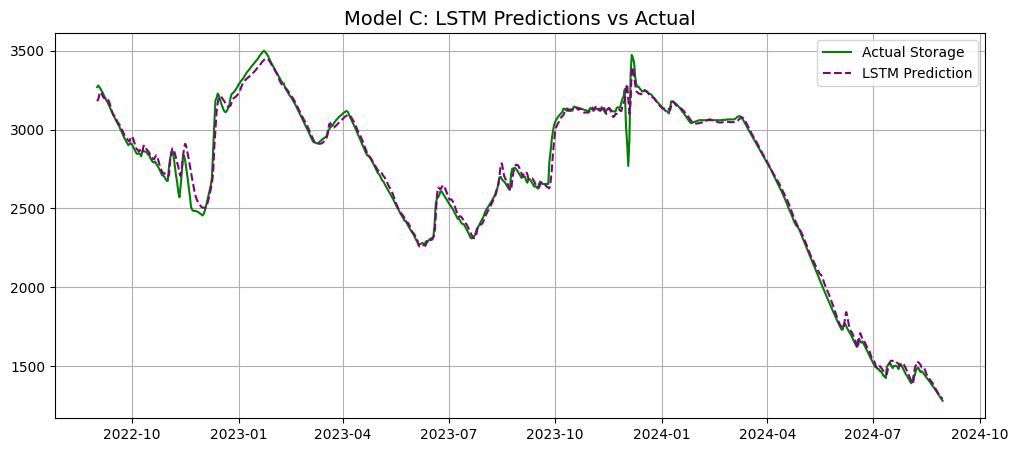

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[-test_days:], inversed_actuals, label='Actual Storage', color='green')
plt.plot(df.index[-test_days:], inversed_predictions, label='LSTM Prediction', color='purple', linestyle='--')
plt.title('LSTM Predictions', fontsize=18)
plt.legend()
plt.grid(True)
plt.show()